In [12]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC

In [13]:
a=pd.read_csv("heart.csv")

In [14]:
a

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [15]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [16]:
a.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [17]:
a.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [18]:
a= pd.get_dummies(a, drop_first = True)
a.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [19]:
X=a.drop(columns=["HeartDisease"],axis=1)
y=a["HeartDisease"]

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [21]:
X_train.shape,X_test.shape

((734, 15), (184, 15))

In [22]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
pd.DataFrame(X_train).head(1)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,-1.245067,-0.708985,0.372803,1.842609,2.284353,-0.097061,0.540605,-0.483336,1.879059,-0.213504,0.808179,-0.487621,-0.838461,-1.03325,-0.847921


## SVM

In [24]:
svc=SVC()

In [25]:
svc.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [26]:
y_pred_svc=svc.predict(X_test)

In [27]:
acc = accuracy_score(y_test,y_pred_svc)
print(acc)

0.875


In [28]:
clf = classification_report(y_test,y_pred_svc)
print("\n",clf)


               precision    recall  f1-score   support

           0       0.84      0.87      0.85        77
           1       0.90      0.88      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



In [29]:
cm = confusion_matrix(y_test,y_pred_svc)
print("\n",cm)


 [[67 10]
 [13 94]]


## KNN

In [30]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
y_pred_knn=knn.predict(X_test)

In [31]:
print("KNN Accuracy :", accuracy_score(y_test,y_pred_knn))

KNN Accuracy : 0.8532608695652174


In [32]:
print("KNN CLF :\n", classification_report(y_test, y_pred_knn))

KNN CLF :
               precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



In [33]:
print("KNN CM :\n", confusion_matrix(y_test, y_pred_knn))

KNN CM :
 [[67 10]
 [17 90]]


In [34]:
k_acc=[]
for k in range(1,11):
  knn_clf = KNeighborsClassifier(n_neighbors=k)
  knn_clf.fit(X_train,y_train)
  y_pred_knn= knn_clf.predict(X_test)
  acc = accuracy_score(y_test,y_pred_knn)
  k_acc.append(acc)

In [35]:
print("List of accuracy: ", k_acc)

List of accuracy:  [0.8206521739130435, 0.7663043478260869, 0.8641304347826086, 0.8315217391304348, 0.8532608695652174, 0.8315217391304348, 0.8967391304347826, 0.875, 0.8858695652173914, 0.875]


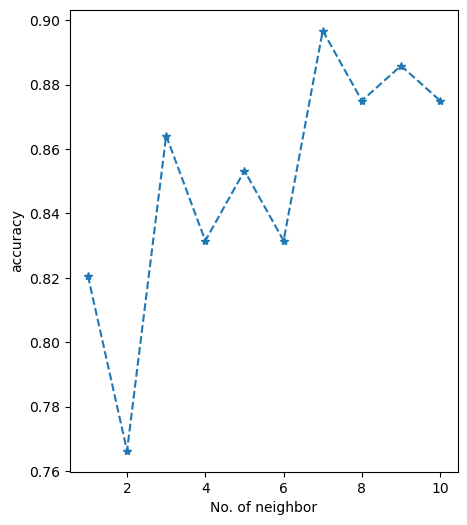

In [36]:
plt.figure(figsize=(5,6))
plt.plot(range(1,11), k_acc, linestyle='--', marker='*')
plt.xlabel("No. of neighbor")
plt.ylabel("accuracy")
plt.show()

In [37]:
max_value=max(k_acc)
optimal_k = k_acc.index(max_value)+1
optimal_k

7

In [38]:
knn_clf = KNeighborsClassifier(n_neighbors=optimal_k, p=2, metric='minkowski')

In [39]:
knn_clf.fit(X_train, y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Naive Bayes

In [40]:
nb = GaussianNB()

In [41]:
nb.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [42]:
y_pred_nb = nb.predict(X_test)

In [43]:
acc = accuracy_score(y_test,y_pred_nb)
print(acc)

0.8586956521739131


In [44]:
clf = classification_report(y_test,y_pred_nb)
print("\n",clf)


               precision    recall  f1-score   support

           0       0.80      0.88      0.84        77
           1       0.91      0.84      0.87       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [45]:
cm = confusion_matrix(y_test,y_pred_nb)
print("\n",cm)


 [[68  9]
 [17 90]]


## Logistic Regression

In [46]:
Lr=LogisticRegression(max_iter = 5000)

In [47]:
Lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [48]:
y_pred_Lr = Lr.predict(X_test)

In [49]:
acc = accuracy_score(y_test,y_pred_Lr)
print(acc)

0.8532608695652174


In [50]:
clf = classification_report(y_test,y_pred_Lr)
print("\n",clf)


               precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



In [51]:
cm = confusion_matrix(y_test,y_pred_Lr)
print("\n",cm)


 [[67 10]
 [17 90]]


## Comparision

In [52]:
from sklearn.metrics import precision_score,recall_score,f1_score

In [53]:
comparision = pd.DataFrame({
    
  "Model":["SVM","KNN","NB","LR"],
  "Accuracy":  [accuracy_score(y_test,y_pred_svc),accuracy_score(y_test,y_pred_knn),accuracy_score(y_test,y_pred_nb),accuracy_score(y_test,y_pred_Lr)],
  "Recall":    [recall_score(y_test,y_pred_svc),recall_score(y_test,y_pred_knn),recall_score(y_test,y_pred_nb),recall_score(y_test,y_pred_Lr)],
  "Precision": [precision_score(y_test,y_pred_svc),precision_score(y_test,y_pred_knn),precision_score(y_test,y_pred_nb),precision_score(y_test,y_pred_Lr)],
  "F1-Score":  [f1_score(y_test,y_pred_svc),f1_score(y_test,y_pred_knn),f1_score(y_test,y_pred_nb),f1_score(y_test,y_pred_Lr)] 
    
})

In [54]:
comparision

,Model,Accuracy,Recall,Precision,F1-Score
0,SVM,0.875000,0.878505,0.903846,0.890995
1,KNN,0.875000,0.869159,0.911765,0.889952
2,NB,0.858696,0.841121,0.909091,0.873786
3,LR,0.853261,0.841121,0.900000,0.869565


In [55]:
comparision.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy,Recall,Precision,F1-Score
0,SVM,0.875000,0.878505,0.903846,0.890995
1,KNN,0.875000,0.869159,0.911765,0.889952
2,NB,0.858696,0.841121,0.909091,0.873786
3,LR,0.853261,0.841121,0.900000,0.869565


In [56]:
comparision = comparision.sort_values(by="Accuracy",ascending=False).reset_index(drop=True)
print(comparision)

  Model  Accuracy    Recall  Precision  F1-Score
0   SVM  0.875000  0.878505   0.903846  0.890995
1   KNN  0.875000  0.869159   0.911765  0.889952
2    NB  0.858696  0.841121   0.909091  0.873786
3    LR  0.853261  0.841121   0.900000  0.869565


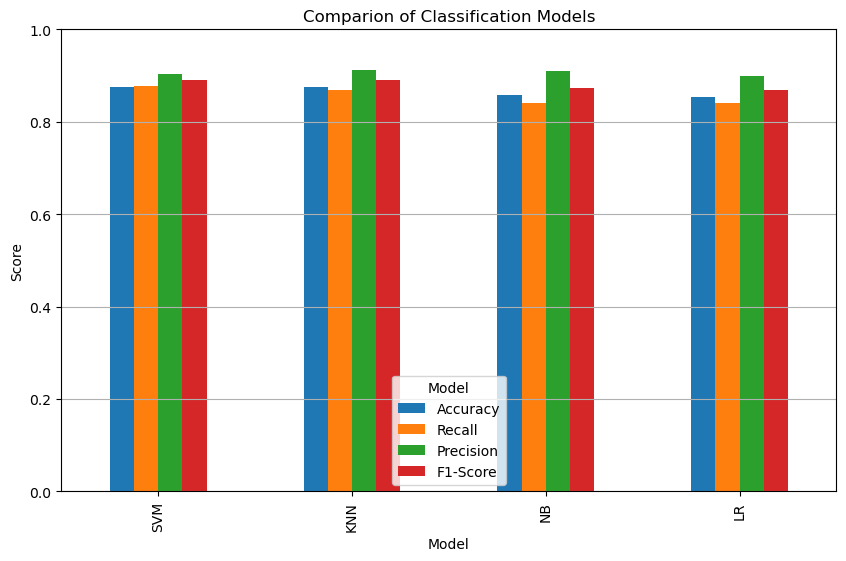

In [57]:
comparision.set_index("Model").plot(kind = "bar", figsize=(10,6))

plt.title("Comparion of Classification Models")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(title = "Model")
plt.grid (axis = "y")
plt.show()

In [ ]:
import joblib

In [ ]:
joblib.dump(svc,"best_model.pkl")

In [ ]:
joblib.dump(scaler,"scaler.pkl")

In [ ]:
joblib.dump(X.columns.tolist(),"feature_columns.pkl")

In [ ]:
joblib.load

In [ ]:
import os 
print(os.getcwd())

In [64]:
import streamlit as st